**Bonus Question 3**

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv


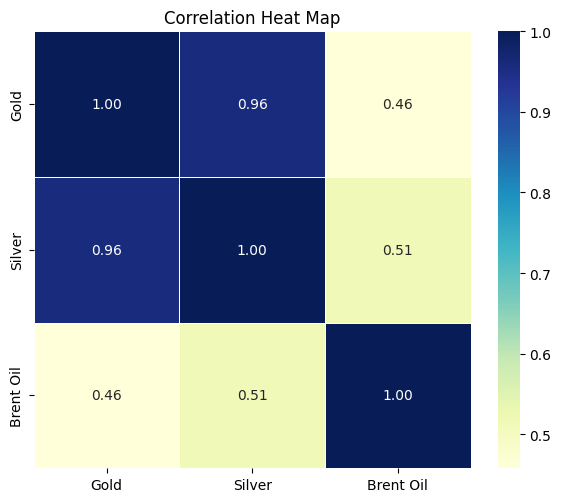

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gold = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv")
silver = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv")
brent = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv")

def prepare(df, name):
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df["Year"] = df["Date"].dt.year
    return df.groupby("Year")["Value"].mean().rename(name)

prices = pd.concat([
    prepare(gold, "Gold"),
    prepare(silver, "Silver"),
    prepare(brent, "Brent Oil")
], axis=1)

correlation = prices.corr()

plt.figure(figsize=(6,5))
sns.heatmap(correlation,
            annot=True,
            cmap="YlGnBu",
            fmt=".2f",
            linewidths=0.5,
            square=True)

plt.title("Correlation Heat Map")
plt.tight_layout()
plt.savefig("Correlation_Heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()